### Imports

In [14]:
# manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# RFR & loss
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
import math

# visualization
import matplotlib.pyplot as plt

# Training Data

### Data to dataframe

The following two lines tell the model where to locate the data, in this case in the Excel sheet from the Downloads folder.

In [15]:
path = ('Path\\To\\Training\\Set\\rmt_training_set.xlsx') 
df = pd.read_excel(path)

This line takes the dataframe (df) and **cleans** it, removing NaN (Not a Number) values that could cause errors in later steps.

In [16]:
dfc = df.dropna() # clean dataframe

Datatypes (dtypes) vary slightly depending on which numbers are being represented. *int64* represents **64-bit integers**, which can store more values than something like a 32-bit integer. *float64* represents a **64-bit floating point number**, which is an integer followed by a decimal. *Objects* are **text-based data**, in this case being used to display tree health and crown spacing.

In [17]:
dfc.dtypes

Collection  Date      int64
Avg 3 day low       float64
Avg 3 day high      float64
Diameter (in)       float64
Cluster Number        int64
Crown Spacing        object
Nearest Tree          int64
Tree Health          object
Volume                int64
dtype: object

It may not be possible to apply operations on text, and therefore a process on objects is carried out called **label encoding**. Columns of datatype 'object' are subject to label encoding, representing them numerically instead of alphabetically. For example, a tree may have an input health variable of *"healthy."* This would be represented as a 1, with other denominations of health being represented as a decimal between 0 and 1 (inclusive.)

### Define Features & Target Variable

Features and target variables are what the model is allowed to know, and what it is attempting to figure out. In this case, every column **up to** Volume is counted as a feature, or what the model is allowed to know, and the Volume column is denoted as the target variable, which the model is attempting to predict.

In [18]:
X = dfc.iloc[:,0:8].values # features
y = dfc.iloc[:,8].values # target variable

"iloc" is a shortened version of "integer location," allowing the model to index the datasheet by columns in which integers occur. This method of searching is not inclusive. For example, *dfc.iloc[:,8]* tells the model to look at the 9th column to find the target variable. *dfc.iloc[:,0:8]* tells the model to look at columns 1-7 for the features.

### Regressor - Label Encoding

The process of label encoding involves splitting the dataset into an alphabetical (categorical) section and a numerical section. Any column with an 'object' datatype is placed into the categorical section and any column with any other kind of datatype is placed into the numerical section. These two sections are then concatenated, or joined on the same axis.

After label encoding, the model itself can be created. 

In [19]:
# check for and handle categorical variables
label_encoder = LabelEncoder()
x_categorical = dfc.drop(columns=['Volume']).select_dtypes(include=['object']).apply(label_encoder.fit_transform)
x_numerical = dfc.drop(columns=['Volume']).select_dtypes(exclude=['object']).values
x = pd.concat([pd.DataFrame(x_numerical), x_categorical], axis=1).values

regressor = RandomForestRegressor(n_estimators=100, random_state=0, oob_score=True)

regressor.fit(x, y)

RandomForestRegressor(oob_score=True, random_state=0)

* The *n_estimators* argument allows specification of how many trees will be in the forest.
* The *random_state* argument is seeded to allow for reproducability, controlling how probability is calculated.
* The *oob_score* stands for the **out of box** score, which is a representation of how well a model performs compared to a relative predictor.

The model itself is fit to **x**, the merged dataframe, and **y**, the target variable.

### Regressor - Evaluation

* **Mean Squared Error** - A measure of loss (error) that squares the distance of an error from the true value. Squaring this distance punishes the model more harshly for mistakes. Better MSE values are closer to zero.
* **R^2 Error** - A measure of a model's accuracy in determining **variance** (distance from values to the average of a dataset.) A good R^2 value is 0.5 <= R^2 < 1

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

predictions = regressor.predict(x)

mse = mean_squared_error(y, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: -0.0907958226395027
Mean Squared Error: 1432.6655519480519
R-squared: 0.8775047472589435


As we can see, the **out-of-bag** score isn't perfect, and the **MSE** is also pretty high. The model did perform well, however, on the **R^2** score.

The most likely reasons for these failures in **oob** and **MSE** scores is a lack of data. Machine learning usually requires thousands of data points within a set, and working with a smaller amount of data (~154 points) can cause **underfitting.**

The line below shows how the model calculated each feature's importance towards predicting sap yield.

In [21]:
dfc.corr(numeric_only=True)['Volume'].sort_values(ascending=False) # descending correlation to volume

Volume              1.000000
Nearest Tree        0.113701
Diameter (in)       0.097686
Collection  Date    0.064473
Avg 3 day high      0.009248
Avg 3 day low      -0.103812
Cluster Number     -0.116356
Name: Volume, dtype: float64

The model correctly discovered that the **distance to the nearest tree** and the **tree's diameter** correlated with sap yield, while other factors such as **cluster number** and **crown spacing** were less important. It mistakenly identified **temperature** as a much less important factor than what was shown by observation. This could be caused by the lack of data from non-ideal temperature values, as a lot of data fell within the perfect conditions for sap harvest.

### Visualization

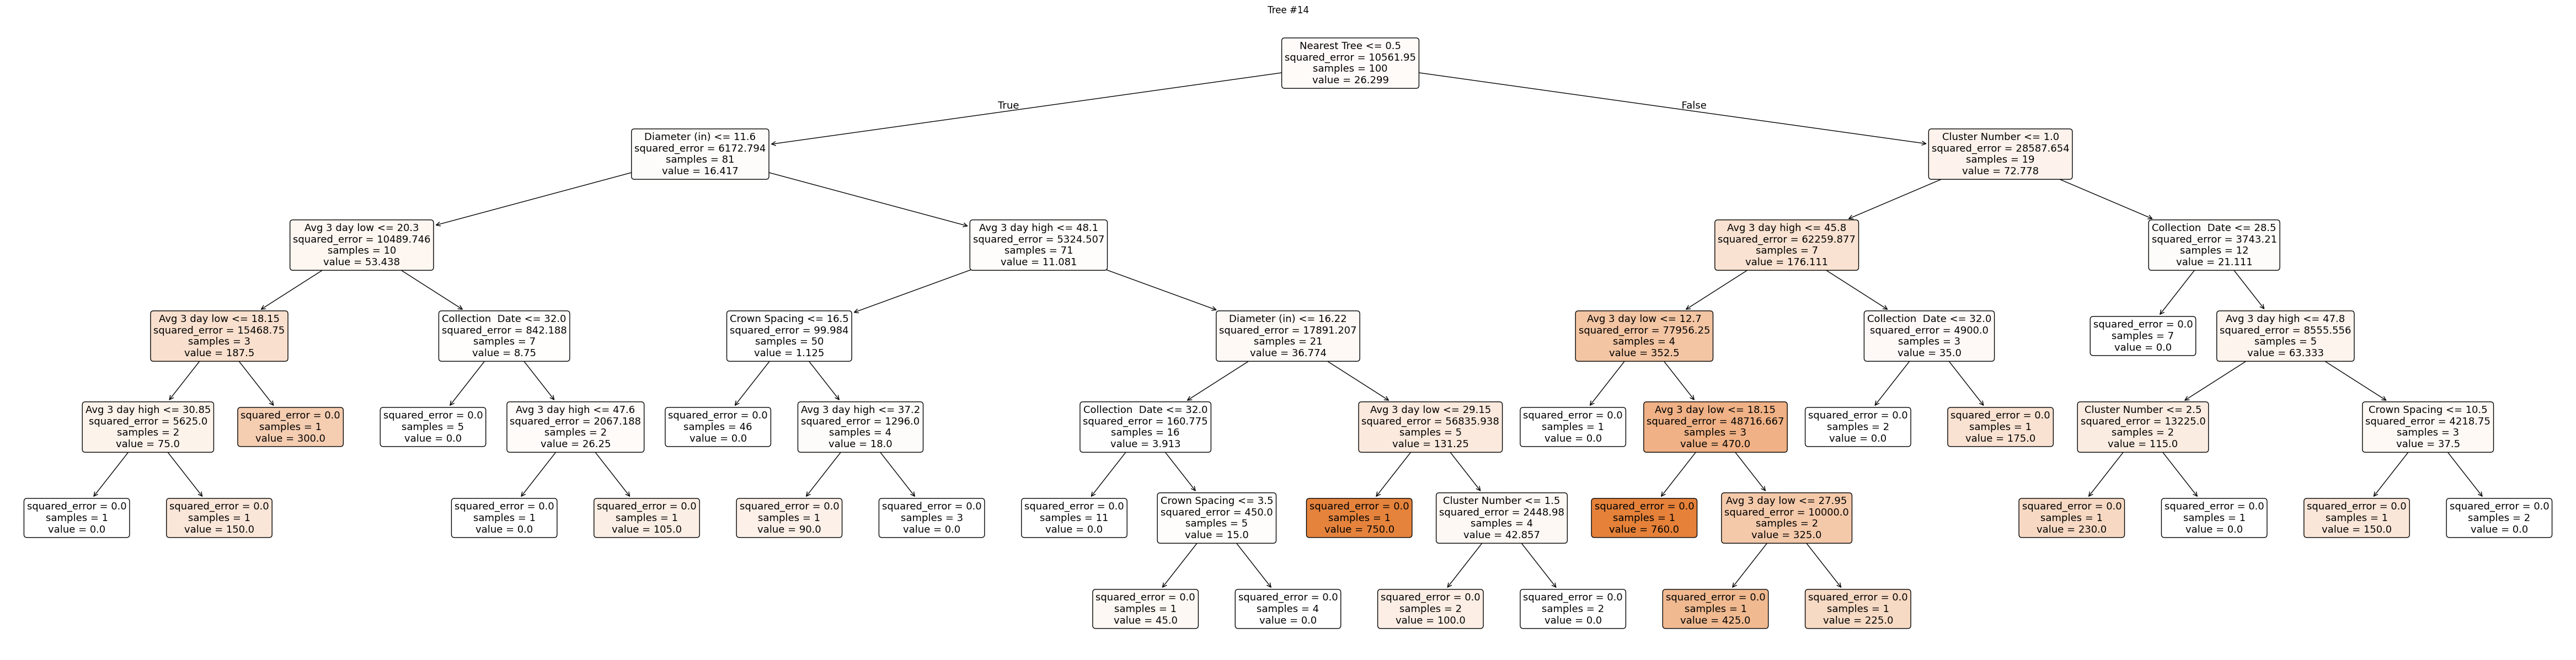

In [22]:
# single decision tree

from sklearn.tree import plot_tree

tree_to_plot = regressor.estimators_[13]

# plot tree
plt.figure(figsize=(60, 15)) # 60 15
plot_tree(tree_to_plot, feature_names=dfc.columns.tolist(), filled=True, rounded=True, fontsize=13)
plt.title("Tree #14")
plt.show()

# Testing Data & Predictions

### Testing Data

In [23]:
testing_data_path = ('Path\\To\\Testing\\Set\\rmt_testing_set.xlsx') 
testing_df = pd.read_excel(testing_data_path)
testing_dfc = testing_df.dropna() # clean data frame

In [24]:
testing_x_categorical = testing_dfc.select_dtypes(include=['object']).apply(label_encoder.fit_transform)
testing_x_numerical = testing_dfc.select_dtypes(exclude=['object']).values
testing_x = pd.concat([pd.DataFrame(testing_x_numerical), testing_x_categorical], axis=1).values

The model can now be used to predict future sap yields. Hypothetical data has been created, some of which can be seen below. Some processes are done (label encoding, concatenation, etc.) to ensure similarity between the testing and training datasets.

In [25]:
testing_dfc.tail(5)

,Collection Date,Avg 3 day low,Avg 3 day high,Diameter (in),Cluster Number,Crown Spacing,Nearest Tree,Tree Health
52,34,32.0,44.1,19.2,4,Competition,12,Healthy
53,34,32.0,44.1,15.6,2,Competition,19,Healthy
54,34,32.0,44.1,13.3,5,Competition,5,Healthy
55,34,32.0,44.1,19.0,3,Competition,5,Somewhat Stressed
56,34,346.0,67.0,2.0,17,Open,789,Stressed


### Predictions

The model has predicted the following values for the **Volume** of the testing dataset, which are reflections of the model's loss scores and the correlation coefficients.

In [26]:
pred = regressor.predict(testing_x)
print(pred)

[ 76.75  28.05  37.8   95.2   83.7   91.15  42.55 134.4   36.05  72.4
 116.45  45.3    0.    52.6  118.6   75.    70.95 160.35  70.15  99.5
 104.4  223.5   88.4  126.85 172.25  66.7    0.    63.4  109.25  15.45
 133.45 109.45  62.8  118.75  34.6  108.65  63.95  91.25 131.6   50.9
   0.45 171.65  46.55  14.25  39.    58.3   23.95  55.1   24.65  69.
  25.    46.9   63.05  20.15   0.    65.45  21.4 ]
